In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

#  SUPERSTORE DATA ANALYSIS PROJECT

#  TASK 1: Load & Explore the Dataset

##  Objective
Load the Superstore dataset into a Pandas DataFrame and understand its structure.

##  Steps Performed
- Import the dataset
- Display first few rows
- Check data types and structure
- Generate summary statistics


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [18]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


#  TASK 2: Data Cleaning

##  Objective
Clean the dataset to ensure it is ready for analysis.

##  Steps Performed
- Identify missing values in the dataset
- Handle missing values appropriately
- Convert date columns to datetime format

In [20]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [22]:
df = df.dropna()  # simplest approach for this dataset

In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

#  TASK 3: Feature Engineering

##  Objective
Create new meaningful features from existing data.

##  Steps Performed
- Extract Year and Month from Order Date
- Create a new numerical feature from existing columns
- Validate correctness of new features

In [25]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [30]:
df['Revenue_Per_Item'] = df['Sales'] / df['Quantity']

In [31]:
df[['Sales', 'Quantity', 'Revenue_Per_Item']].head()

,Sales,Quantity,Revenue_Per_Item
0,261.9600,2,130.9800
1,731.9400,3,243.9800
2,14.6200,2,7.3100
3,957.5775,5,191.5155
4,22.3680,2,11.1840


#  TASK 4: GroupBy & Aggregation Analysis

##  Objective
Summarize the dataset to extract key business insights.

##  Steps Performed
- Calculate total sales by category
- Calculate total profit by region
- Identify top 5 customers based on sales
- Analyze monthly sales trends

In [32]:
df.groupby('Category')['Sales'].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [34]:
df.groupby('Region')['Profit'].sum()

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

In [33]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64

In [35]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum()
monthly_sales

Year  Month
2014  1         14236.8950
      2          4519.8920
      3         55691.0090
      4         28295.3450
      5         23648.2870
      6         34595.1276
      7         33946.3930
      8         27909.4685
      9         81777.3508
      10        31453.3930
      11        78628.7167
      12        69545.6205
2015  1         18174.0756
      2         11951.4110
      3         38726.2520
      4         34195.2085
      5         30131.6865
      6         24797.2920
      7         28765.3250
      8         36898.3322
      9         64595.9180
      10        31404.9235
      11        75972.5635
      12        74919.5212
2016  1         18542.4910
      2         22978.8150
      3         51715.8750
      4         38750.0390
      5         56987.7280
      6         40344.5340
      7         39261.9630
      8         31115.3743
      9         73410.0249
      10        59687.7450
      11        79411.9658
      12        96999.0430
2017  1         

# TASK 5: Pivot Tables

## Objective
Reshape data to analyze multiple dimensions at once.

##  Steps Performed
- Create pivot table for sales by category and region
- Analyze sales trends by segment over time
- Compute profit by sub-category

In [36]:
pd.pivot_table(df, values='Sales', index='Category', columns='Region', aggfunc='sum')

Region,Central,East,South,West
Category,,,,
Furniture,163797.1638,208291.204,117298.684,252612.7435
Office Supplies,167026.4150,205516.055,125651.313,220853.2490
Technology,170416.3120,264973.981,148771.908,251991.8320


In [37]:
pd.pivot_table(df, values='Sales', index='Month', columns='Segment', aggfunc='sum')

Segment,Consumer,Corporate,Home Office
Month,,,
1,50441.2906,26790.3480,17693.1970
2,33826.1760,14575.0670,11350.0084
3,89174.7070,58239.9132,57590.8686
4,54845.1895,49233.1636,33683.7755
5,86932.7144,47289.0323,20807.0650
6,82910.1803,40858.5370,28949.9620
7,81769.7730,46919.2060,18549.1180
8,82319.8063,57529.4477,19194.8090
9,185055.9196,74020.2213,48573.8048


In [38]:
pd.pivot_table(df, values='Profit', index='Sub-Category', aggfunc='sum')

,Profit
Sub-Category,
Accessories,41936.6357
Appliances,18138.0054
Art,6527.7870
Binders,30221.7633
Bookcases,-3472.5560
Chairs,26590.1663
Copiers,55617.8249
Envelopes,6964.1767
Fasteners,949.5182


# TASK 6: Data Splitting & Merging

##  Objective
Practice dataset manipulation using splitting and merging.

##  Steps Performed
- Split dataset into meaningful subsets
- Merge subsets back into a single dataset
- Validate merged dataset integrity


In [39]:
df_sales = df[['Order ID', 'Customer Name', 'Sales', 'Profit']]
df_info = df[['Order ID', 'Category', 'Region', 'Segment']]

In [40]:
merged_df = pd.merge(df_sales, df_info, on='Order ID')

In [42]:
merged_df.head()

,Order ID,Customer Name,Sales,Profit,Category,Region,Segment
0,CA-2016-152156,Claire Gute,261.96,41.9136,Furniture,South,Consumer
1,CA-2016-152156,Claire Gute,261.96,41.9136,Furniture,South,Consumer
2,CA-2016-152156,Claire Gute,731.94,219.5820,Furniture,South,Consumer
3,CA-2016-152156,Claire Gute,731.94,219.5820,Furniture,South,Consumer
4,CA-2016-138688,Darrin Van Huff,14.62,6.8714,Office Supplies,West,Corporate


#  TASK 7: Data Visualization

##  Objective
Visualize data to identify patterns and insights.

##  Steps Performed
- Line chart for sales trends over time
- Bar chart for sales by category
- Bar chart for profit by region
- Pie chart for segment distribution


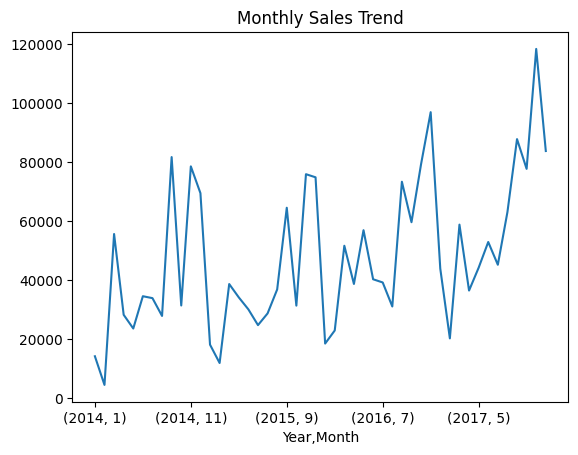

In [43]:
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()

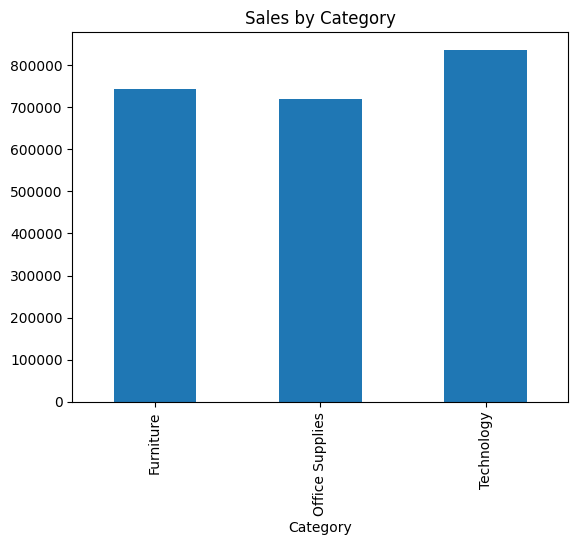

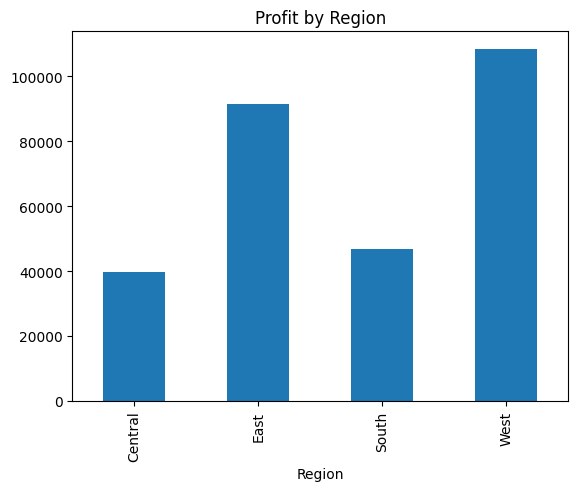

In [45]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()
df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Region")
plt.show()

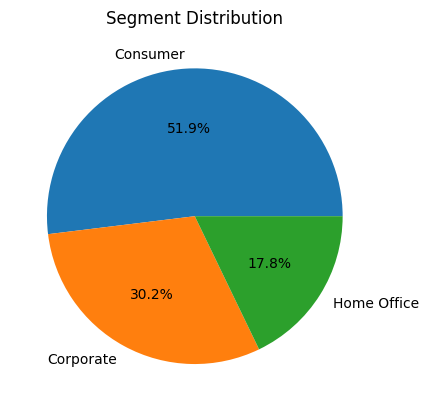

In [46]:
df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Segment Distribution")
plt.ylabel("")
plt.show()

#  TASK 8: Business Insights & Findings

##  Objective
Extract meaningful business conclusions from the analysis.

##  Key Insights to Identify
- Most profitable category
- Least performing region
- Relationship between sales and profit
- Important sales trends over time

In [47]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [48]:
df.groupby('Region')['Profit'].sum().sort_values()

Region
Central     39706.3625
South       46749.4303
East        91522.7800
West       108418.4489
Name: Profit, dtype: float64

In [49]:
df[['Sales', 'Profit']].corr()

,Sales,Profit
Sales,1.000000,0.479064
Profit,0.479064,1.000000
